# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset:

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib as plt

In [3]:
#creating dataframe
df = pd.read_csv('Coffee Sales.csv')

## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [4]:
#I started by checking the number of rows and columns
df.shape

(3547, 11)

In [5]:
#Then I got a quick glimpse at the first 5 rows
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [6]:
#And the last five rows
df.tail()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,18:11:38.635000


In [7]:
#I then used info to understand the structure of the dataset. 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [8]:
#then used describe for a quick statistical analysis.
df.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [9]:
#moved on to check for missing values in each column to make sure there were no gaps
df.isna().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [10]:
#I checked for duplicate rows to ensure no drink orders were counted twice
df.duplicated().sum()

np.int64(0)

In [11]:
#then checked the unique values in each column to undestand the variety of the data
df.nunique()

hour_of_day      17
cash_type         1
money            13
coffee_name       8
Time_of_Day       3
Weekday           7
Month_name       12
Weekdaysort       7
Monthsort        12
Date            381
Time           3547
dtype: int64

In [ ]:
#then I used value_counts on multiple columns to spot trends and patterns

#looking at the hour column showed me which hours had the most orders
df['hour_of_day'].value_counts().sort_index()

hour_of_day
6       5
7      88
8     235
9     242
10    328
11    283
12    241
13    225
14    225
15    236
16    278
17    237
18    218
19    229
20    169
21    195
22    113
Name: count, dtype: int64

In [13]:
#The Time_of_Day column showed me whether the most orders happened in the morning, afternoon, or night
df['Time_of_Day'].value_counts().sort_index()

Time_of_Day
Afternoon    1205
Morning      1181
Night        1161
Name: count, dtype: int64

In [14]:
#looking at the weekday column showed me which days were busiest
df['Weekday'].value_counts()

Weekday
Tue    572
Mon    544
Fri    532
Thu    510
Wed    500
Sat    470
Sun    419
Name: count, dtype: int64

In [ ]:
#and the coffee_name column showed me which drinks were ordered the most 
df['coffee_name'].value_counts().sort_values(ascending=False)

coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Hot Chocolate          276
Cocoa                  239
Espresso               129
Name: count, dtype: int64

## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

<Axes: >

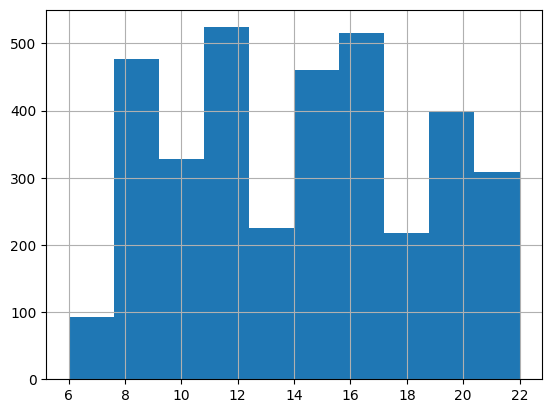

In [16]:
#I chose histograms to get a quick sense of overall patterns

#hour of day showed how customer traffic changed throughout the day
df['hour_of_day'].hist()

<Axes: >

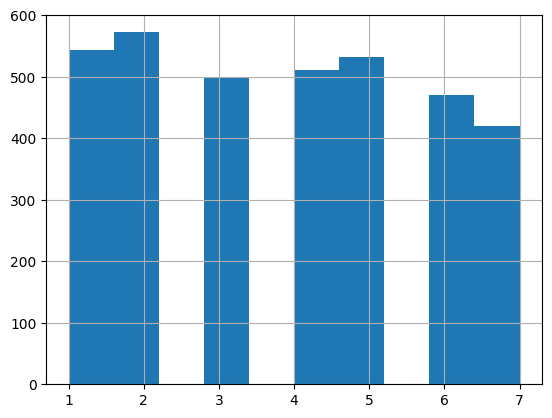

In [17]:
#weekday sort showed how sales were spread across the week
df['Weekdaysort'].hist() 

## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset? 
    -- I was surprised how late the time goes, I didn't expect to see so mnay night time coffee sales.
2. Do you have any concerns about your dataset? 
    -- No concernes yet
3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data? 
    -- The column name format is inconsistent, so I will be changing that. There isnt any missing or null data, so that is nice. There also isnt any duplicated data. 